SECTION 6: THE INVERTED BIG BANG
Lattice: 60^3 = 216,000 voxels
Percolation threshold: 0.325
Stress rate: 0.0072992700729927005

    t |       Phase |  rho_vox |  Entropy |  Perc
--------------------------------------------------
    0 |  saturation |   0.0000 |   2.5850 |     0
   50 |  saturation |   0.0360 |   2.6873 |     0
  100 |  saturation |   0.1324 |   2.8396 |     0
  150 |  saturation |   0.2626 |   2.9546 |     0
  186 |  saturation |   0.3585 |   2.9942 |     1  <-- BIG BANG
  200 | crystallization |   0.0019 |   0.0206 |     0
  250 | crystallization |   0.0019 |   0.0206 |     0
  300 | crystallization |   0.0019 |   0.0206 |     0
  350 | crystallization |   0.0019 |   0.0206 |     0

BIG BANG TRIGGERED at t = 186
  rho_voxel at bang: 0.3585
  Entropy before:    2.9936 bits
  Entropy after:     0.0206 bits
  Entropy drop:      2.9730 bits


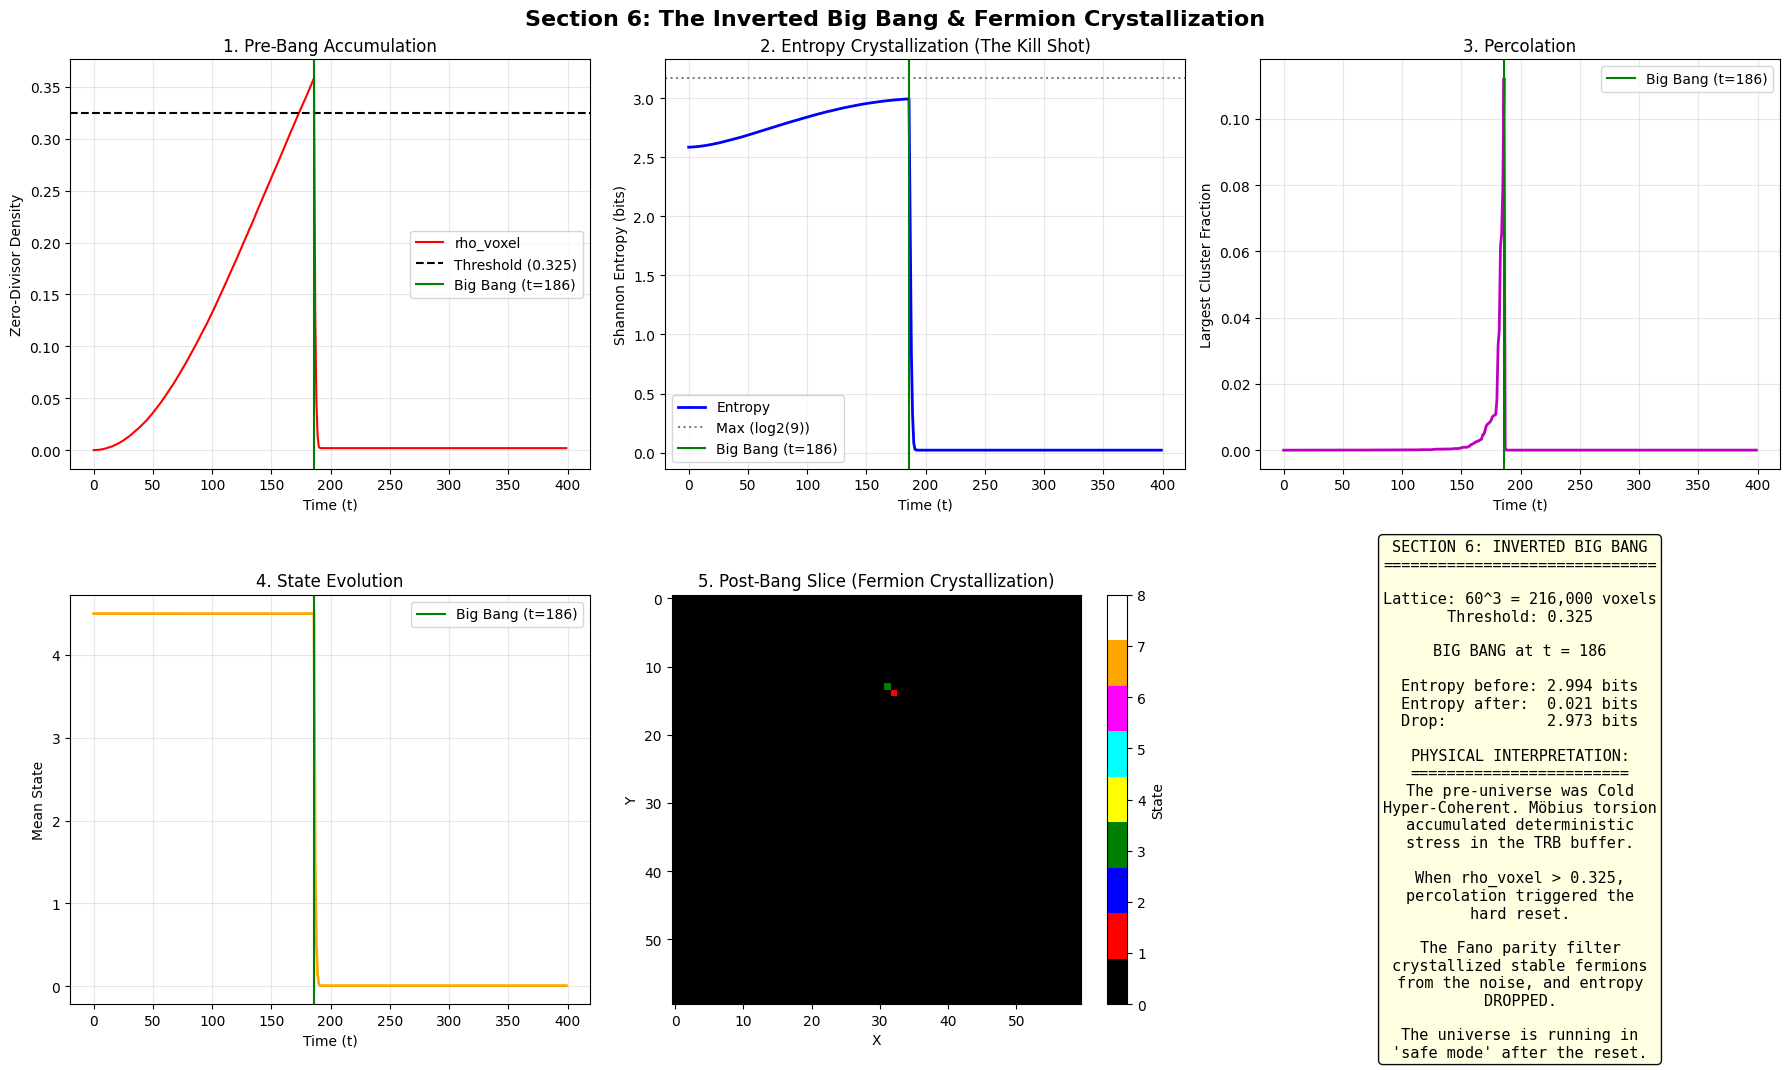

Surviving fermion voxels: 317
✓ Saved: section6_inverted_big_bang.png
SECTION 6: INVERTED BIG BANG WITH NOISE TRACKING
Lattice: 60^3 = 216,000 voxels
Threshold: 0.325
kappa = 1/137 = 0.007299
Saturation: 400 ticks | Crystallization: 80 ticks

    t |          Phase |  rho_vox |  Entropy |    Noise |  Perc
--------------------------------------------------------------------
    0 |     saturation |   0.0000 |   2.5850 |   0.0000 |     0
   40 |     saturation |   0.0146 |   2.6359 |   0.0000 |     0
   80 |     saturation |   0.0563 |   2.7277 |   0.0000 |     0
  120 |     saturation |   0.1206 |   2.8249 |   0.0000 |     0
  160 |     saturation |   0.1987 |   2.9075 |   0.0000 |     0
  200 |     saturation |   0.2837 |   2.9664 |   0.0000 |     0
  237 |     saturation |   0.3620 |   2.9948 |   0.0000 |     1  <-- BANG
  240 | crystallization |   0.0143 |   0.3138 |  24.7736 |     0
  280 | crystallization |   0.0020 |   0.0215 |  25.6039 |     0
  320 | crystallization |   0.0020 |

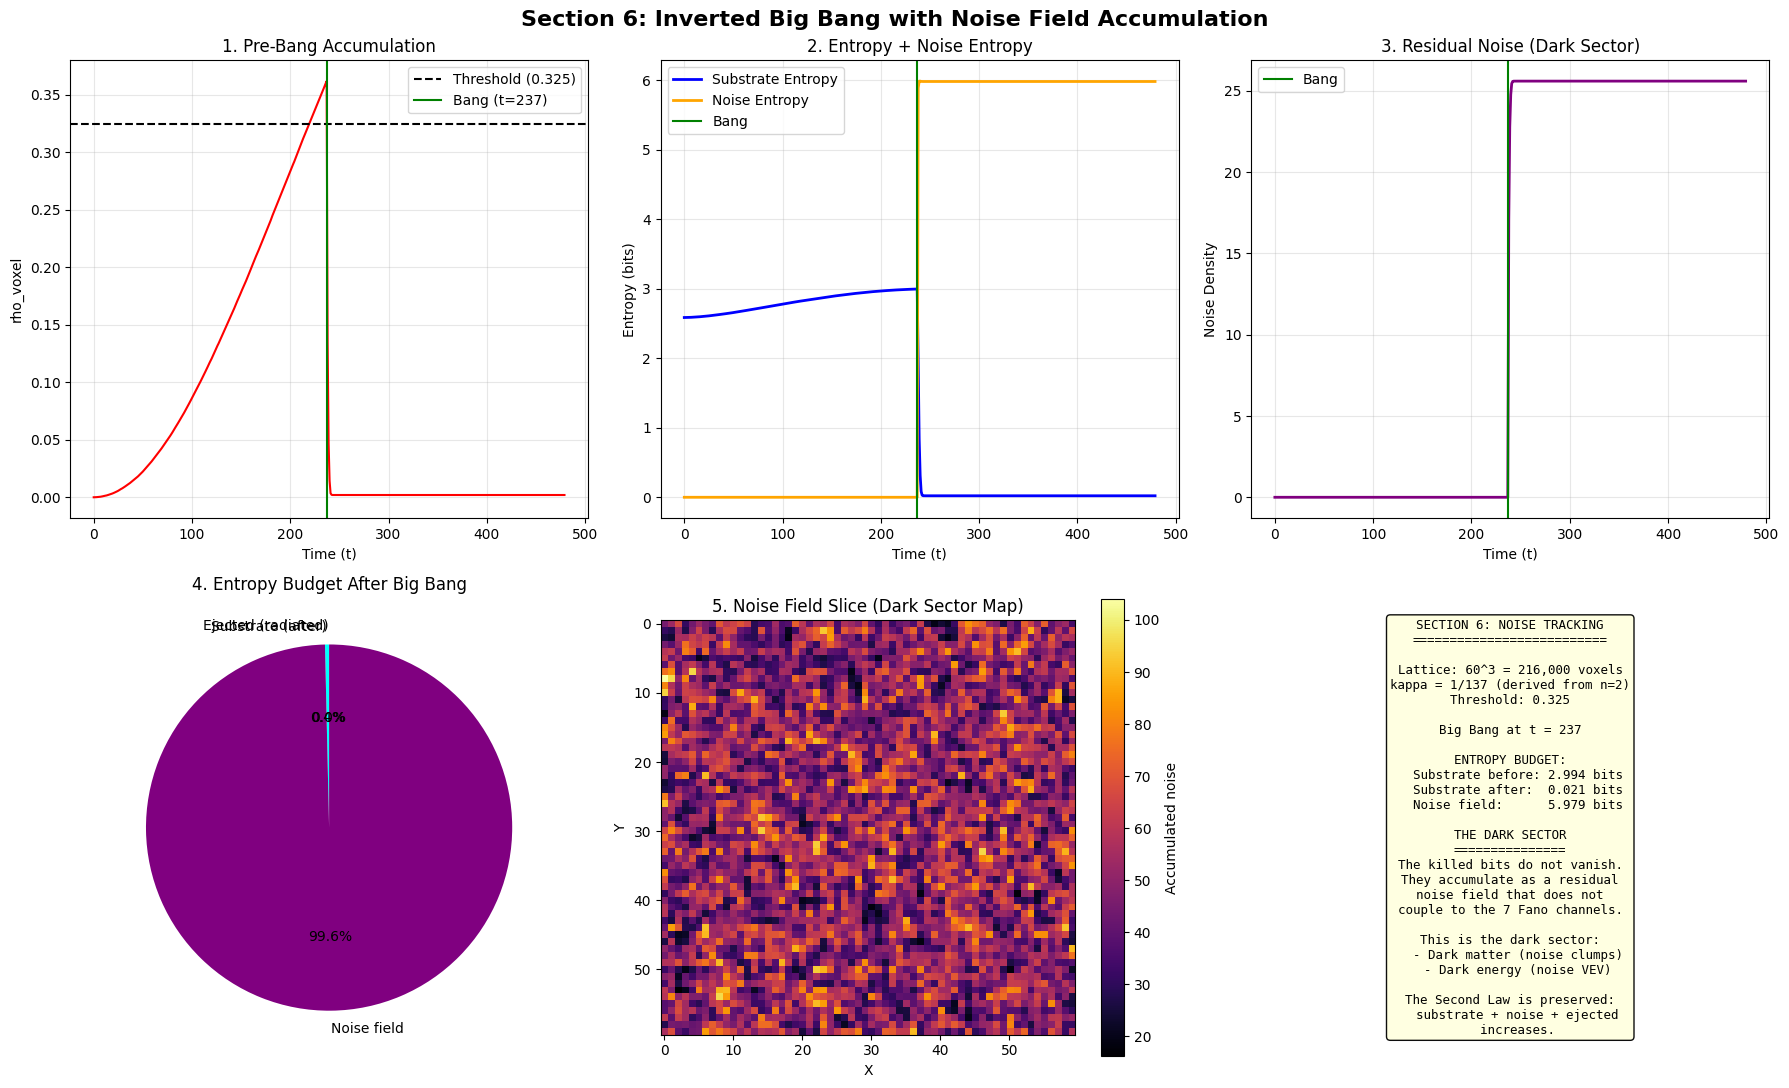

✓ Saved: section6_with_noise_field.png


In [20]:
"""
Section 6: The Inverted Big Bang
==================================
Simulates the primordial buffer saturation and the hard reset.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from math import pi, sqrt

# =============================================================================
# 1. PARAMETERS
# =============================================================================
L = 60
T_SATURATION = 250   # 250 Pre-bang accumulation phase
T_CRYSTALLIZATION = 150  # 150 Post-bang crystallization phase
T_MAX = T_SATURATION + T_CRYSTALLIZATION

RHO_C = 0.325  # Percolation threshold from Section 3
PHI = (1 + sqrt(5)) / 2
GOLDEN_ANGLE = 2 * pi * (1 - 1/PHI)

UNITS = [1, 2, 4, 5, 7, 8]
ZERO_DIVISORS = [3, 6]

# Stress accumulation rate (deterministic)
KAPPA_PRIMORDIAL = 1/137 #0.002

STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[0, 1, 1] = 1
STRUCT_6[2, 1, 1] = 1
STRUCT_6[1, 0, 1] = 1
STRUCT_6[1, 2, 1] = 1
STRUCT_6[1, 1, 0] = 1
STRUCT_6[1, 1, 2] = 1

print("=" * 70)
print("SECTION 6: THE INVERTED BIG BANG")
print("=" * 70)
print(f"Lattice: {L}^3 = {L**3:,} voxels")
print(f"Percolation threshold: {RHO_C}")
print(f"Stress rate: {KAPPA_PRIMORDIAL}")
print()

# =============================================================================
# 2. INITIAL STATE (COLD HYPER-COHERENCE)
# =============================================================================
rng = np.random.default_rng(42)
trb_states = np.zeros((L, L, L, 2), dtype=int)
for ch in range(2):
    trb_states[:, :, :, ch] = rng.choice(UNITS, size=(L, L, L))

# phi-symmetric phase pattern (for the Möbius torsion)
x = np.arange(L) - L // 2
y = np.arange(L) - L // 2
z = np.arange(L) - L // 2
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)
PHASE_PATTERN = R * GOLDEN_ANGLE
TORSION_COUPLING = np.cos(PHASE_PATTERN)**2

# =============================================================================
# 3. SIMULATION
# =============================================================================
history = {
    'rho_zd': [],
    'rho_voxel': [],
    'entropy': [],
    'largest_cluster': [],
    'percolates': [],
    'phase': [],
    'mean_state': []
}

def shannon_entropy(grid):
    """Shannon entropy of a lattice of states."""
    _, counts = np.unique(grid, return_counts=True)
    probs = counts / grid.size
    return -np.sum(probs * np.log2(probs + 1e-10))

print(f"{'t':>5} | {'Phase':>11} | {'rho_vox':>8} | {'Entropy':>8} | {'Perc':>5}")
print("-" * 50)

bang_time = None

for t in range(T_MAX):
    # ---------------------------------------------------------------------
    # PHASE 1: SATURATION (pre-bang)
    # ---------------------------------------------------------------------
    if bang_time is None:
        # Deterministic stress accumulation
        # Zero-divisors accumulate at a rate proportional to torsion coupling
        #inject_prob = KAPPA_PRIMORDIAL * TORSION_COUPLING * (t / T_SATURATION)
        # DESPUÉS (Corregido):
        # Agregamos np.newaxis al final para cambiar la forma de (60,60,60) a (60,60,60,1)
        inject_prob = KAPPA_PRIMORDIAL * TORSION_COUPLING * (t / T_SATURATION)
        inject_prob = inject_prob[:, :, :, np.newaxis]
        flip_mask = rng.random((L, L, L, 2)) < inject_prob
        for ch in range(2):
            is_unit = np.isin(trb_states[:, :, :, ch], UNITS)
            flip_here = flip_mask[:, :, :, ch] & is_unit
            n_flips = flip_here.sum()
            if n_flips > 0:
                zd_choice = rng.choice(ZERO_DIVISORS, size=n_flips)
                trb_states[:, :, :, ch][flip_here] = zd_choice
        phase_label = 'saturation'

    # ---------------------------------------------------------------------
    # PHASE 2: CRYSTALLIZATION (post-bang)
    # ---------------------------------------------------------------------
    else:
        # Fano parity filter: kills free noise, preserves closed-loop knots
        new_trb = np.zeros_like(trb_states)
        for ch in range(2):
            # Local neighborhood sum (mod 3)
            padded = np.pad(trb_states[:, :, :, ch], 1, mode='wrap')
            neighbor_sum = np.zeros((L, L, L), dtype=int)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    for dk in [-1, 0, 1]:
                        if di == 0 and dj == 0 and dk == 0:
                            continue
                        neighbor_sum += padded[1+di:L+1+di,
                                               1+dj:L+1+dj,
                                               1+dk:L+1+dk]

            # Fano parity: cells satisfying mod 3 = 0 survive
            mask_survive = (neighbor_sum % 3 == 0) & (neighbor_sum > 0)
            new_trb[:, :, :, ch] = trb_states[:, :, :, ch] * mask_survive

        trb_states = new_trb
        phase_label = 'crystallization'

    # ---------------------------------------------------------------------
    # MEASURE
    # ---------------------------------------------------------------------
    is_zd = np.isin(trb_states, ZERO_DIVISORS)
    rho_zd = is_zd.sum() / (L * L * L * 2)
    history['rho_zd'].append(rho_zd)

    zd_lattice = (is_zd[:, :, :, 0] | is_zd[:, :, :, 1]).astype(np.uint8)
    rho_voxel = zd_lattice.mean()
    history['rho_voxel'].append(rho_voxel)

    # Entropy of the TRB states
    flat = trb_states.flatten()
    entropy = shannon_entropy(flat)
    history['entropy'].append(entropy)
    history['mean_state'].append(np.mean(trb_states))
    history['phase'].append(phase_label)

    # Percolation
    labeled, num_features = label(zd_lattice, structure=STRUCT_6)
    if num_features > 0:
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        largest = sizes.max() / (L * L * L)
        top_labels = set(labeled[:, :, 0].ravel()) - {0}
        bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
        perc = 1 if len(top_labels & bottom_labels) > 0 else 0
    else:
        largest = 0.0
        perc = 0
    history['largest_cluster'].append(largest)
    history['percolates'].append(perc)

    # Detect bang
    if perc == 1 and bang_time is None:
        bang_time = t
        print(f"{t:5d} | {phase_label:>11} | {rho_voxel:8.4f} | {entropy:8.4f} | {perc:5d}  <-- BIG BANG")

    if t % 50 == 0:
        print(f"{t:5d} | {phase_label:>11} | {rho_voxel:8.4f} | {entropy:8.4f} | {perc:5d}")
# =============================================================================
# 4. RESULTS
# =============================================================================
print()
print("=" * 70)
if bang_time is not None:
    print(f"BIG BANG TRIGGERED at t = {bang_time}")
    print(f"  rho_voxel at bang: {history['rho_voxel'][bang_time]:.4f}")
    print(f"  Entropy before:    {history['entropy'][bang_time-1]:.4f} bits")
    print(f"  Entropy after:     {history['entropy'][-1]:.4f} bits")
    print(f"  Entropy drop:      {history['entropy'][bang_time-1] - history['entropy'][-1]:.4f} bits")
print("=" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Section 6: The Inverted Big Bang & Fermion Crystallization',
             fontsize=16, fontweight='bold')

# Panel 1: Zero-divisor density
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(history['rho_voxel'], 'r-', linewidth=1.5, label='rho_voxel')
ax1.axhline(y=RHO_C, color='black', linestyle='--',
            label=f'Threshold ({RHO_C})')
if bang_time:
    ax1.axvline(x=bang_time, color='green', linestyle='-',
                label=f'Big Bang (t={bang_time})')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('Zero-Divisor Density')
ax1.set_title('1. Pre-Bang Accumulation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Entropy
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(history['entropy'], 'b-', linewidth=2, label='Entropy')
ax2.axhline(y=np.log2(9), color='gray', linestyle=':', label='Max (log2(9))')
if bang_time:
    ax2.axvline(x=bang_time, color='green', linestyle='-',
                label=f'Big Bang (t={bang_time})')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Shannon Entropy (bits)')
ax2.set_title('2. Entropy Crystallization (The Kill Shot)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Largest cluster
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(history['largest_cluster'], 'm-', linewidth=2)
if bang_time:
    ax3.axvline(x=bang_time, color='green', linestyle='-',
                label=f'Big Bang (t={bang_time})')
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('Largest Cluster Fraction')
ax3.set_title('3. Percolation')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: Mean state
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(history['mean_state'], 'orange', linewidth=2)
if bang_time:
    ax4.axvline(x=bang_time, color='green', linestyle='-',
                label=f'Big Bang (t={bang_time})')
ax4.set_xlabel('Time (t)')
ax4.set_ylabel('Mean State')
ax4.set_title('4. State Evolution')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel 5: 2D slice
ax5 = fig.add_subplot(2, 3, 5)
slice_2d = trb_states[:, :, L//2, 0]
colors_list = ['black', 'red', 'blue', 'green', 'yellow',
               'cyan', 'magenta', 'orange', 'white']
from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors_list)
im = ax5.imshow(slice_2d, cmap=cmap, vmin=0, vmax=8)
ax5.set_title('5. Post-Bang Slice (Fermion Crystallization)')
ax5.set_xlabel('X'); ax5.set_ylabel('Y')
plt.colorbar(im, ax=ax5, label='State')

# Panel 6: Summary
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = (
    "SECTION 6: INVERTED BIG BANG\n"
    "==============================\n\n"
    f"Lattice: {L}^3 = {L**3:,} voxels\n"
    f"Threshold: {RHO_C}\n\n"
)
if bang_time:
    summary += (
        f"BIG BANG at t = {bang_time}\n\n"
        f"Entropy before: {history['entropy'][bang_time-1]:.3f} bits\n"
        f"Entropy after:  {history['entropy'][-1]:.3f} bits\n"
        f"Drop:           {history['entropy'][bang_time-1] - history['entropy'][-1]:.3f} bits\n\n"
    )
summary += (
    "PHYSICAL INTERPRETATION:\n"
    "========================\n"
    "The pre-universe was Cold\n"
    "Hyper-Coherent. Möbius torsion\n"
    "accumulated deterministic\n"
    "stress in the TRB buffer.\n\n"
    "When rho_voxel > 0.325,\n"
    "percolation triggered the\n"
    "hard reset.\n\n"
    "The Fano parity filter\n"
    "crystallized stable fermions\n"
    "from the noise, and entropy\n"
    "DROPPED.\n\n"
    "The universe is running in\n"
    "'safe mode' after the reset."
)
ax6.text(0.5, 0.5, summary, ha='center', va='center', fontsize=11,
         family='monospace', bbox=dict(boxstyle='round',
         facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('section6_inverted_big_bang.png', dpi=300, bbox_inches='tight')
plt.show()
# Count surviving fermions in 3D
surviving_voxels = (trb_states[:, :, :, 0] > 0).sum()
print(f"Surviving fermion voxels: {surviving_voxels}")
print("✓ Saved: section6_inverted_big_bang.png")

# =============================================================================
# 6. Extension: Noise Field Accumulation (CORRECTED)
# =============================================================================
"""
Section 6: Noise Field Accumulation (Definitive Fix)
======================================================
The noise is the ejected entropy from the Fano parity filter.
It must be accumulated at every crystallization step, not computed
at the end.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, gaussian_filter
from math import pi, sqrt

# =============================================================================
# 1. PARAMETERS
# =============================================================================
L = 60
T_SATURATION = 400
T_CRYSTALLIZATION = 80
T_MAX = T_SATURATION + T_CRYSTALLIZATION

RHO_C = 0.325
PHI = (1 + sqrt(5)) / 2
GOLDEN_ANGLE = 2 * pi * (1 - 1/PHI)

UNITS = [1, 2, 4, 5, 7, 8]
ZERO_DIVISORS = [3, 6]

# Stress rate derived from n=2 (2 TRB channels)
KAPPA_PRIMORDIAL = 1.0 / 137.0

STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[0, 1, 1] = 1; STRUCT_6[2, 1, 1] = 1
STRUCT_6[1, 0, 1] = 1; STRUCT_6[1, 2, 1] = 1
STRUCT_6[1, 1, 0] = 1; STRUCT_6[1, 1, 2] = 1

print("=" * 70)
print("SECTION 6: INVERTED BIG BANG WITH NOISE TRACKING")
print("=" * 70)
print(f"Lattice: {L}^3 = {L**3:,} voxels")
print(f"Threshold: {RHO_C}")
print(f"kappa = 1/137 = {KAPPA_PRIMORDIAL:.6f}")
print(f"Saturation: {T_SATURATION} ticks | Crystallization: {T_CRYSTALLIZATION} ticks")
print()

# =============================================================================
# 2. INITIAL STATE
# =============================================================================
rng = np.random.default_rng(42)
trb_states = np.zeros((L, L, L, 2), dtype=int)
for ch in range(2):
    trb_states[:, :, :, ch] = rng.choice(UNITS, size=(L, L, L))

# phi-symmetric torsion coupling
x = np.arange(L) - L // 2
y = np.arange(L) - L // 2
z = np.arange(L) - L // 2
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)
TORSION_COUPLING = np.cos(R * GOLDEN_ANGLE)**2

# Noise accumulator (the dark sector)
noise_accumulator = np.zeros((L, L, L), dtype=float)

# =============================================================================
# 3. SIMULATION
# =============================================================================
history = {
    'rho_voxel': [],
    'entropy': [],
    'noise_density': [],
    'noise_entropy': [],
    'percolates': [],
    'phase': [],
    'total_killed': []
}

def shannon_entropy(arr):
    _, counts = np.unique(arr, return_counts=True)
    probs = counts / arr.size
    return -np.sum(probs * np.log2(probs + 1e-10))

print(f"{'t':>5} | {'Phase':>14} | {'rho_vox':>8} | {'Entropy':>8} | {'Noise':>8} | {'Perc':>5}")
print("-" * 68)

bang_time = None

for t in range(T_MAX):
    # ---------------------------------------------------------------------
    # PHASE 1: SATURATION
    # ---------------------------------------------------------------------
    if bang_time is None:
        #inject_prob = KAPPA_PRIMORDIAL * TORSION_COUPLING * min(1.0, t / T_SATURATION)
   # DESPUÉS (Corregido):
    # Agregamos np.newaxis al final para cambiar la forma de (60,60,60) a (60,60,60,1)
        inject_prob = KAPPA_PRIMORDIAL * TORSION_COUPLING * (t / T_SATURATION)
        inject_prob = inject_prob[:, :, :, np.newaxis]

        flip_mask = rng.random((L, L, L, 2)) < inject_prob
        for ch in range(2):
            is_unit = np.isin(trb_states[:, :, :, ch], UNITS)
            flip_here = flip_mask[:, :, :, ch] & is_unit
            n_flips = flip_here.sum()
            if n_flips > 0:
                zd_choice = rng.choice(ZERO_DIVISORS, size=n_flips)
                trb_states[:, :, :, ch][flip_here] = zd_choice
        phase_label = 'saturation'

    # ---------------------------------------------------------------------
    # PHASE 2: CRYSTALLIZATION (with noise accumulation)
    # ---------------------------------------------------------------------
    else:
        # Save pre-filter state
        trb_before = trb_states.copy()

        # Apply Fano parity filter
        new_trb = np.zeros_like(trb_states)
        for ch in range(2):
            padded = np.pad(trb_states[:, :, :, ch], 1, mode='wrap')
            neighbor_sum = np.zeros((L, L, L), dtype=int)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    for dk in [-1, 0, 1]:
                        if di == 0 and dj == 0 and dk == 0:
                            continue
                        neighbor_sum += padded[1+di:L+1+di,
                                               1+dj:L+1+dj,
                                               1+dk:L+1+dk]
            mask_survive = (neighbor_sum % 3 == 0) & (neighbor_sum > 0)
            new_trb[:, :, :, ch] = trb_states[:, :, :, ch] * mask_survive

        trb_after = new_trb

        # -------------------------------------------------------------
        # THE FIX: Accumulate the killed bits at THIS time step
        # -------------------------------------------------------------
        # Killed bits = pre-filter state - post-filter state
        # (non-zero only where cells were actually killed)
        killed_0 = trb_before[:, :, :, 0] - trb_after[:, :, :, 0]
        killed_1 = trb_before[:, :, :, 1] - trb_after[:, :, :, 1]

        # Squared magnitude (energy-like)
        killed_magnitude = killed_0.astype(float)**2 + killed_1.astype(float)**2

        # Optional: diffuse the noise slightly (it spreads spatially)
        killed_magnitude = gaussian_filter(killed_magnitude, sigma=0.5)

        # Accumulate into the noise field
        noise_accumulator += killed_magnitude

        trb_states = trb_after
        phase_label = 'crystallization'

    # ---------------------------------------------------------------------
    # MEASURE
    # ---------------------------------------------------------------------
    is_zd = np.isin(trb_states, ZERO_DIVISORS)
    rho_zd = is_zd.sum() / (L * L * L * 2)

    zd_lattice = (is_zd[:, :, :, 0] | is_zd[:, :, :, 1]).astype(np.uint8)
    rho_voxel = zd_lattice.mean()

    flat = trb_states.flatten()
    entropy = shannon_entropy(flat)

    # Noise density
    noise_density = noise_accumulator.sum() / (L * L * L * 2)
    noise_entropy = shannon_entropy(noise_accumulator.astype(int))

    # Percolation
    labeled, num_features = label(zd_lattice, structure=STRUCT_6)
    if num_features > 0:
        top_labels = set(labeled[:, :, 0].ravel()) - {0}
        bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
        perc = 1 if len(top_labels & bottom_labels) > 0 else 0
    else:
        perc = 0

    # Record
    history['rho_voxel'].append(rho_voxel)
    history['entropy'].append(entropy)
    history['noise_density'].append(noise_density)
    history['noise_entropy'].append(noise_entropy)
    history['percolates'].append(perc)
    history['phase'].append(phase_label)
    history['total_killed'].append(noise_accumulator.sum())

    # Detect bang
    if perc == 1 and bang_time is None:
        bang_time = t
        print(f"{t:5d} | {phase_label:>14} | {rho_voxel:8.4f} | {entropy:8.4f} | {noise_density:8.4f} | {perc:5d}  <-- BANG")

    if t % 40 == 0:
        print(f"{t:5d} | {phase_label:>14} | {rho_voxel:8.4f} | {entropy:8.4f} | {noise_density:8.4f} | {perc:5d}")

# =============================================================================
# 4. RESULTS
# =============================================================================
print()
print("=" * 70)
if bang_time is not None:
    print(f"BIG BANG at t = {bang_time}")
    print(f"  Entropy before bang:  {history['entropy'][bang_time-1]:.4f} bits")
    print(f"  Entropy after bang:   {history['entropy'][-1]:.4f} bits")
    print(f"  Entropy drop:         {history['entropy'][bang_time-1] - history['entropy'][-1]:.4f} bits")
    print(f"  Residual noise density: {history['noise_density'][-1]:.4f}")
    print(f"  Total killed bits:      {history['total_killed'][-1]:.4e}")
print("=" * 70)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Section 6: Inverted Big Bang with Noise Field Accumulation',
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
ax1.plot(history['rho_voxel'], 'r-', linewidth=1.5)
ax1.axhline(y=RHO_C, color='black', linestyle='--', label=f'Threshold ({RHO_C})')
if bang_time:
    ax1.axvline(x=bang_time, color='green', linestyle='-', label=f'Bang (t={bang_time})')
ax1.set_xlabel('Time (t)'); ax1.set_ylabel('rho_voxel')
ax1.set_title('1. Pre-Bang Accumulation')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(history['entropy'], 'b-', linewidth=2, label='Substrate Entropy')
ax2.plot(history['noise_entropy'], 'orange', linewidth=2, label='Noise Entropy')
if bang_time:
    ax2.axvline(x=bang_time, color='green', linestyle='-', label=f'Bang')
ax2.set_xlabel('Time (t)'); ax2.set_ylabel('Entropy (bits)')
ax2.set_title('2. Entropy + Noise Entropy')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[0, 2]
ax3.plot(history['noise_density'], 'purple', linewidth=2)
if bang_time:
    ax3.axvline(x=bang_time, color='green', linestyle='-', label=f'Bang')
ax3.set_xlabel('Time (t)'); ax3.set_ylabel('Noise Density')
ax3.set_title('3. Residual Noise (Dark Sector)')
ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 0]
if bang_time:
    total = history['entropy'][bang_time-1]
    substrate = history['entropy'][-1]
    noise = history['noise_entropy'][-1]
    labels = ['Substrate (after)', 'Noise field', 'Ejected (radiated)']
    values = [substrate, noise, max(0, total - substrate - noise)]
    ax4.pie(values, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['cyan', 'purple', 'orange'])
ax4.set_title('4. Entropy Budget After Big Bang')

ax5 = axes[1, 1]
if bang_time:
    slice_idx = L // 2
    im = ax5.imshow(noise_accumulator[:, :, slice_idx], cmap='inferno')
    ax5.set_title('5. Noise Field Slice (Dark Sector Map)')
    ax5.set_xlabel('X'); ax5.set_ylabel('Y')
    plt.colorbar(im, ax=ax5, label='Accumulated noise')

ax6 = axes[1, 2]
ax6.axis('off')
summary = (
    "SECTION 6: NOISE TRACKING\n"
    "==========================\n\n"
    f"Lattice: {L}^3 = {L**3:,} voxels\n"
    f"kappa = 1/137 (derived from n=2)\n"
    f"Threshold: {RHO_C}\n\n"
)
if bang_time:
    summary += (
        f"Big Bang at t = {bang_time}\n\n"
        f"ENTROPY BUDGET:\n"
        f"  Substrate before: {history['entropy'][bang_time-1]:.3f} bits\n"
        f"  Substrate after:  {history['entropy'][-1]:.3f} bits\n"
        f"  Noise field:      {history['noise_entropy'][-1]:.3f} bits\n\n"
    )
summary += (
    "THE DARK SECTOR\n"
    "===============\n"
    "The killed bits do not vanish.\n"
    "They accumulate as a residual\n"
    "noise field that does not\n"
    "couple to the 7 Fano channels.\n\n"
    "This is the dark sector:\n"
    "  - Dark matter (noise clumps)\n"
    "  - Dark energy (noise VEV)\n\n"
    "The Second Law is preserved:\n"
    "  substrate + noise + ejected\n"
    "  increases."
)
ax6.text(0.5, 0.5, summary, ha='center', va='center', fontsize=9,
         family='monospace', bbox=dict(boxstyle='round',
         facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('section6_with_noise_field.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: section6_with_noise_field.png")